# Import Libraries

Grid search fusion weight alpha untuk:

```
prob_fused = alpha * prob_text + (1 - alpha) * prob_image
```

In [1]:
import json
import pickle
import re
from pathlib import Path
from urllib.parse import unquote, urlparse
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix


I0000 00:00:1782271518.319785   82343 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782271518.321476   82343 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782271518.496979   82343 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782271519.892350   82343 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [2]:
def clean_url(url):
    parsed = urlparse(url)
    url = parsed.netloc + parsed.path
    url = unquote(url).lower()
    url = re.sub(r"https?:\/\/", "", url)
    url = re.sub(r"[-_/]", " ", url)
    url = re.sub(r"[^a-zA-Z0-9\s]", " ", url)
    url = re.sub(r"(\d)([a-z])", r"\1 \2", url)
    url = re.sub(r"([a-z])(\d)", r"\1 \2", url)
    url = re.sub(r"\s+", " ", url).strip()
    return url

In [3]:
BASE_DIR = Path(".")
BIN_DIR = BASE_DIR / "bin"
CSV_PATH = BASE_DIR / "dataset" / "dataset_crawl_070526_with_images_path.csv"

# Load Models

In [4]:
text_model = tf.keras.models.load_model(str(BIN_DIR / 'text_classifier.keras'))
with open(BIN_DIR / 'text_tfidf_vectorizer.pkl', 'rb') as f:
    text_vectorizer = pickle.load(f)
with open(BIN_DIR / 'text_best_threshold.json') as f:
    text_cfg = json.load(f)
text_threshold = text_cfg.get('best_threshold', 0.63)
print(f'Text threshold: {text_threshold:.2f}')

E0000 00:00:1782271521.248649   82343 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Text threshold: 0.63


In [5]:
image_model = tf.keras.models.load_model(str(BIN_DIR / 'image_classifier.keras'))
image_scaler = joblib.load(BIN_DIR / 'image_scaler.pkl')
with open(BIN_DIR / 'image_best_threshold.json') as f:
    image_cfg = json.load(f)
image_threshold = image_cfg['threshold']
print(f'Image threshold: {image_threshold:.2f}')
print(f'Image model: {type(image_model).__name__}')

Image threshold: 0.64
Image model: Sequential


# Load Dataset

In [6]:
df = pd.read_csv(CSV_PATH)
mask = df["Screenshot_Path"].notna() & (df["Screenshot_Path"] != "")
df_img = df[mask].copy().reset_index(drop=True)
X_img = np.load(BIN_DIR / 'image_features.npy')
img_ids = np.load(BIN_DIR / 'image_ids.npy')
id_map = {i: idx for idx, i in enumerate(img_ids)}
order = [id_map[wid] for wid in df_img["Webpage_id"]]
X_img = X_img[order]
y = (df_img["Tag"] == "gambling").astype(int).values
print(f'Samples: {len(df_img)}')
print(f'Gambling: {y.sum()} / Non-gambling: {(1 - y).sum()}')

Samples: 37811
Gambling: 12503 / Non-gambling: 25308


In [7]:
groups = df_img["Domain"].values

gkf = StratifiedGroupKFold(n_splits=5)

oof_text_probs = np.zeros(len(df_img))
oof_image_probs = np.zeros(len(df_img))

# Predictions from Both Models

In [8]:
for fold, (train_idx, val_idx) in enumerate(
    gkf.split(df_img, y, groups),
    1,
):

    print(f"\nFold {fold}/5")

    # ===================================
    # TEXT MODEL
    # ===================================

    X_text_train = (
        df_img.iloc[train_idx]["Url"]
        .apply(clean_url)
        .values
    )

    X_text_val = (
        df_img.iloc[val_idx]["Url"]
        .apply(clean_url)
        .values
    )

    X_train_tfidf = text_vectorizer.transform(X_text_train)
    X_val_tfidf = text_vectorizer.transform(X_text_val)

    fold_text_model = tf.keras.models.clone_model(
        text_model
    )

    fold_text_model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.0005
        ),
        loss="binary_crossentropy",
    )

    fold_text_model.fit(
        X_train_tfidf,
        y[train_idx],
        epochs=20,
        batch_size=64,
        verbose=0,
    )

    oof_text_probs[val_idx] = (
        fold_text_model.predict(
            X_val_tfidf,
            verbose=0,
        )
        .ravel()
    )

    # ===================================
    # IMAGE MODEL (Deep Learning)
    # ===================================

    fold_image_model = tf.keras.models.clone_model(image_model)
    fold_image_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005, amsgrad=True),
        loss='binary_crossentropy',
    )

    fold_image_model.fit(
        X_img[train_idx],
        y[train_idx],
        epochs=20,
        batch_size=64,
        verbose=0,
    )

    oof_image_probs[val_idx] = (
        fold_image_model
        .predict(
            X_img[val_idx],
            verbose=0,
        )
        .ravel()
    )


Fold 1/5

Fold 2/5

Fold 3/5

Fold 4/5

Fold 5/5


In [9]:
prob_text = oof_text_probs
prob_image = oof_image_probs

# Grid Search Fusion Weight Alpha

In [10]:
results = []
best_alpha, best_f1, best_th = 0.5, 0.0, 0.5
for alpha in np.arange(0.0, 1.05, 0.05):
    prob_fused = alpha * prob_text + (1.0 - alpha) * prob_image
    best_f1_alpha, best_th_alpha = 0.0, 0.5
    for th in np.arange(0.3, 0.85, 0.02):
        f1 = f1_score(y, (prob_fused >= th).astype(int))
        if f1 > best_f1_alpha:
            best_f1_alpha, best_th_alpha = f1, th
    results.append({'alpha': round(alpha, 2), 'threshold': round(float(best_th_alpha), 2), 'f1': round(float(best_f1_alpha), 4)})
    if best_f1_alpha > best_f1:
        best_f1, best_alpha, best_th = best_f1_alpha, alpha, best_th_alpha

In [11]:
results_df = pd.DataFrame(results)
display(results_df)
text_f1 = f1_score(y, (prob_text >= text_threshold).astype(int))
image_f1 = f1_score(y, (prob_image >= image_threshold).astype(int))
print(f'\nText-only F1 (th={text_threshold:.2f}):  {text_f1:.4f}')
print(f'Image-only F1 (th={image_threshold:.2f}): {image_f1:.4f}')
print(f'\nBest alpha: {best_alpha:.2f}')
print(f'Threshold: {best_th:.2f}')
print(f'Fusion F1: {best_f1:.4f}')

,alpha,threshold,f1
0,0.00,0.38,0.8735
1,0.05,0.40,0.8787
2,0.10,0.36,0.8848
3,0.15,0.36,0.8914
4,0.20,0.36,0.8988
5,0.25,0.40,0.9065
6,0.30,0.30,0.9217
7,0.35,0.34,0.9298
8,0.40,0.40,0.9434
9,0.45,0.44,0.9556



Text-only F1 (th=0.63):  0.9623
Image-only F1 (th=0.64): 0.8593

Best alpha: 0.50
Threshold: 0.50
Fusion F1: 0.9798


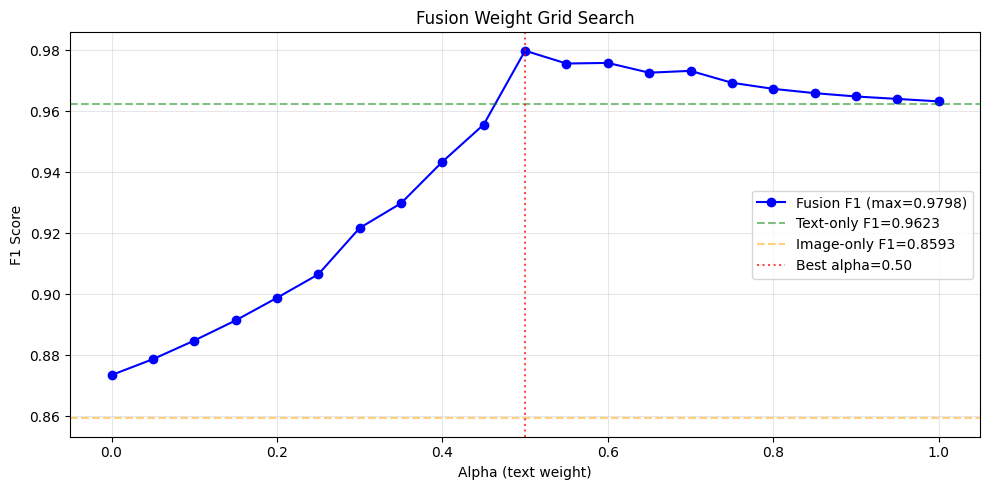

In [25]:
best_f1 = results_df['f1'].max()

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(
    results_df['alpha'],
    results_df['f1'],
    'bo-',
    label=f'Fusion F1 (max={best_f1:.4f})'
)

ax1.axhline(
    text_f1,
    color='green',
    linestyle='--',
    alpha=0.5,
    label=f'Text-only F1={text_f1:.4f}'
)

ax1.axhline(
    image_f1,
    color='orange',
    linestyle='--',
    alpha=0.5,
    label=f'Image-only F1={image_f1:.4f}'
)

ax1.axvline(
    best_alpha,
    color='red',
    linestyle=':',
    alpha=0.7,
    label=f'Best alpha={best_alpha:.2f}'
)

ax1.set_xlabel('Alpha (text weight)')
ax1.set_ylabel('F1 Score')
ax1.set_title('Fusion Weight Grid Search')
ax1.legend()
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Text Model Evaluation

In [13]:
# Find optimal threshold for text on this subset
best_text_f1, best_text_th = 0.0, 0.5
for th in np.arange(0.3, 0.85, 0.02):
    f1 = f1_score(y, (prob_text >= th).astype(int))
    if f1 > best_text_f1:
        best_text_f1, best_text_th = f1, th
print(f'Text optimal threshold on subset: {best_text_th:.2f}')
print(f'Text F1 on subset: {best_text_f1:.4f}')

Text optimal threshold on subset: 0.54
Text F1 on subset: 0.9632


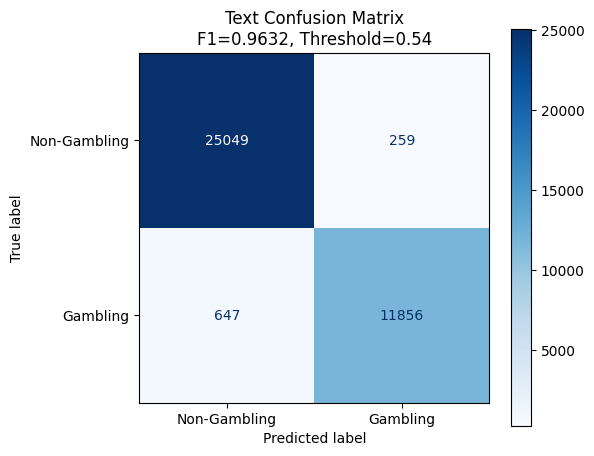

Confusion Matrix (text):
[[25049   259]
 [  647 11856]]


In [14]:
text_pred_subset = (prob_text >= best_text_th).astype(int)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y, text_pred_subset,
    display_labels=["Non-Gambling", "Gambling"],
    cmap="Blues", values_format="d", ax=ax,
)
ax.set_title(f"Text Confusion Matrix\nF1={best_text_f1:.4f}, Threshold={best_text_th:.2f}")
plt.tight_layout()
plt.show()
cm = confusion_matrix(y, text_pred_subset)
print("Confusion Matrix (text):")
print(cm)

In [15]:
print("\n=== Text Classification Report ===")
print(classification_report(y, text_pred_subset, target_names=["Non-Gambling", "Gambling"], digits=4))


=== Text Classification Report ===
              precision    recall  f1-score   support

Non-Gambling     0.9748    0.9898    0.9822     25308
    Gambling     0.9786    0.9483    0.9632     12503

    accuracy                         0.9760     37811
   macro avg     0.9767    0.9690    0.9727     37811
weighted avg     0.9761    0.9760    0.9759     37811



# Image Model Evaluation

In [16]:
# Find optimal threshold for image on this subset
best_image_f1, best_image_th = 0.0, 0.5
for th in np.arange(0.3, 0.85, 0.02):
    f1 = f1_score(y, (prob_image >= th).astype(int))
    if f1 > best_image_f1:
        best_image_f1, best_image_th = f1, th
print(f'Image optimal threshold on subset: {best_image_th:.2f}')
print(f'Image F1 on subset: {best_image_f1:.4f}')

Image optimal threshold on subset: 0.38
Image F1 on subset: 0.8735


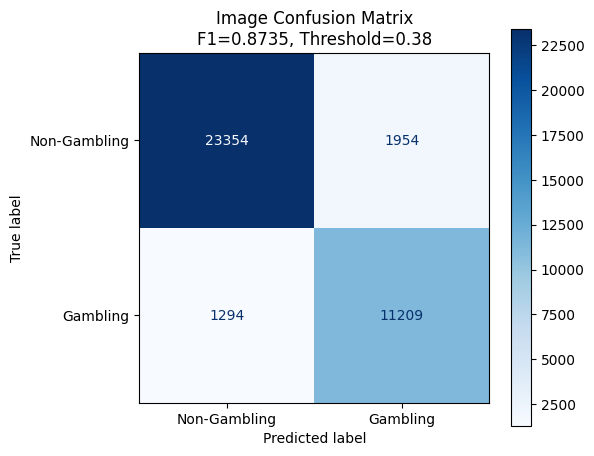

Confusion Matrix (image):
[[23354  1954]
 [ 1294 11209]]


In [17]:
image_pred_subset = (prob_image >= best_image_th).astype(int)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y, image_pred_subset,
    display_labels=["Non-Gambling", "Gambling"],
    cmap="Blues", values_format="d", ax=ax,
)
ax.set_title(f"Image Confusion Matrix\nF1={best_image_f1:.4f}, Threshold={best_image_th:.2f}")
plt.tight_layout()
plt.show()
cm = confusion_matrix(y, image_pred_subset)
print("Confusion Matrix (image):")
print(cm)

In [18]:
print("\n=== Image Classification Report ===")
print(classification_report(y, image_pred_subset, target_names=["Non-Gambling", "Gambling"], digits=4))


=== Image Classification Report ===
              precision    recall  f1-score   support

Non-Gambling     0.9475    0.9228    0.9350     25308
    Gambling     0.8516    0.8965    0.8735     12503

    accuracy                         0.9141     37811
   macro avg     0.8995    0.9096    0.9042     37811
weighted avg     0.9158    0.9141    0.9146     37811



# Fusion Model Evaluation

In [19]:
best_prob_fused = (
    best_alpha * prob_text
    + (1.0 - best_alpha) * prob_image
)

best_pred = (
    best_prob_fused >= best_th
).astype(int)

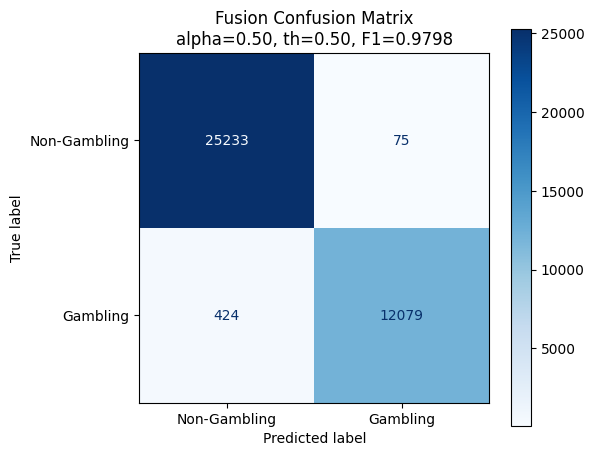

Confusion Matrix (fusion):
[[25233    75]
 [  424 12079]]


In [20]:
fig, ax = plt.subplots(
    figsize=(6, 5)
)

ConfusionMatrixDisplay.from_predictions(
    y,
    best_pred,
    display_labels=[
        "Non-Gambling",
        "Gambling",
    ],
    cmap="Blues",
    values_format="d",
    ax=ax,
)

ax.set_title(
    f"Fusion Confusion Matrix\n"
    f"alpha={best_alpha:.2f}, "
    f"th={best_th:.2f}, "
    f"F1={best_f1:.4f}"
)

plt.tight_layout()
plt.show()
cm = confusion_matrix(y, best_pred)
print("Confusion Matrix (fusion):")
print(cm)

In [22]:
print("\n=== Fusion Classification Report ===")
print(classification_report(y, best_pred, target_names=["Non-Gambling", "Gambling",], digits=4,))


=== Fusion Classification Report ===
              precision    recall  f1-score   support

Non-Gambling     0.9835    0.9970    0.9902     25308
    Gambling     0.9938    0.9661    0.9798     12503

    accuracy                         0.9868     37811
   macro avg     0.9887    0.9816    0.9850     37811
weighted avg     0.9869    0.9868    0.9868     37811



# Save Optimal Alpha

In [21]:
output = {'alpha': float(best_alpha), 'threshold': float(best_th), 'f1': float(best_f1)}
with open(BIN_DIR / 'image_fusion_alpha.json', 'w') as f:
    json.dump(output, f)
print(f'Saved to {BIN_DIR / "image_fusion_alpha.json"}')
print(json.dumps(output, indent=2))

Saved to bin/image_fusion_alpha.json
{
  "alpha": 0.5,
  "threshold": 0.5000000000000002,
  "f1": 0.9797623392951291
}
